# Import Essential Libraries 

In [2]:
# Libraries
import utils as ut
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import plot_tree

# Step 8. Supervised Learning & Model Selection
### **Introduction & Objectives**
    - Our goal is to build a predictive model that can identify whether a shipment will be late or not. We will follow an iterative approach to find the best balance between predictive power, model complexity, and file size for deployment.

* **The Experimental Strategy**
    - **Baseline Modeling (Decision Tree)**:
        - We will start with a **Decision Tree Classifier**. As a model, it will allow us to visualize the initial logic and identify which features (like shipping mode or region) are the primary drivers of delays.
        - We will test the model across multiple variations of our data (Normalized, Scaled, and with/without Outliers) to see how the data structure affects tree depth.

* **Ensemble Optimization (Random Forest)**:
    - Once a baseline is established, we will move to **Random Forest**. By aggregating 150 different trees, we aim to reduce the "variance" (overfitting) common in single trees and improve overall accuracy.
    - **Constraint Management**: A key objective is to ensure the final model is "ready." This means we will intentionally tune hyperparameters like max_depth to ensure the model file is efficient enough to be hosted on GitHub and loaded into our future web application.

* **Evaluation Metrics**:
    - We will primarily use Accuracy Score to evaluate performance, while also monitoring Tree Depth to ensure our models are learning general patterns rather than just memorizing the training set.

## 8.1 Reading the Processed Dataset

In [3]:
# We will use the train set to train the model.
X_train_WITH_outliers = ut.pd.read_csv("../data/processed/X_train_WITH_outliers.csv")
X_train_WITH_outliers_norm = ut.pd.read_csv("../data/processed/X_train_WITH_outliers_norm.csv")
X_train_WITH_outliers_scal = ut.pd.read_csv("../data/processed/X_train_WITH_outliers_scal.csv")
X_train_WITHOUT_outliers = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers.csv")
X_train_WITHOUT_outliers_norm = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers_norm.csv")
X_train_WITHOUT_outliers_scal = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers_scal.csv")
y_train = ut.pd.read_csv("../data/processed/y_train.csv")

TEST DT WITH PARAMS

## 8.2 Select the Best Dataset

In [4]:
datasets = [
    X_train_WITH_outliers,
    X_train_WITH_outliers_norm,
    X_train_WITH_outliers_scal,
    X_train_WITHOUT_outliers,
    X_train_WITHOUT_outliers_norm,
    X_train_WITHOUT_outliers_scal
]

# Define names for clarity
dataset_names = [
    "WITH_outliers", "WITH_outliers_norm", "WITH_outliers_scal",
    "WITHOUT_outliers", "WITHOUT_outliers_norm", "WITHOUT_outliers_scal"
]
best_metric = 0
best_dataset_name = ""
metrics = []
for i, dataset in enumerate(datasets):
  print(f"Training on {dataset_names[i]}...")
  dt_model = ut.DecisionTreeClassifier(random_state= 10)
  dt_model.fit(dataset, y_train.values.ravel())
  y_pred = dt_model.predict(datasets[i])
  metric = ut.accuracy_score(y_train, y_pred)
  metrics.append(metric)
  # Only save the data/metrics for the winner, don't keep all models in a list
  if metric > best_metric:
      best_metric = metric
      best_dataset_name = dataset_names[i]
      best_index = i
    
  # Clear the model from memory before the next loop in case Kernel crashes
  # del dt_model

print(f"\nAll runs complete!")
print(f"Scores: {metrics}")
print(f"The best DataSet is: {best_dataset_name} at index {best_index}")

Training on WITH_outliers...
Training on WITH_outliers_norm...
Training on WITH_outliers_scal...
Training on WITHOUT_outliers...
Training on WITHOUT_outliers_norm...
Training on WITHOUT_outliers_scal...

All runs complete!
Scores: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
The best DataSet is: WITH_outliers at index 0


### For the above result of the scoring having all of then just 1s, it might be a Overfitting and Metric Incompatibility.

## 8.3 Initialization and Training of the Model
- In this case, I will use the test dataset to avoid any overfiting for the decision tree model.

In [5]:
# We need the test sets ready to properly evaluate decision tree
X_test_WITH_outliers = ut.pd.read_csv("../data/processed/X_test_WITH_outliers.csv")
X_test_WITH_outliers_norm = ut.pd.read_csv("../data/processed/X_test_WITH_outliers_norm.csv")
X_test_WITH_outliers_scal = ut.pd.read_csv("../data/processed/X_test_WITH_outliers_scal.csv")
X_test_WITHOUT_outliers = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers.csv")
X_test_WITHOUT_outliers_norm = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers_norm.csv")
X_test_WITHOUT_outliers_scal = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers_scal.csv")
y_test = ut.pd.read_csv("../data/processed/y_test.csv").values.ravel()

test_datasets = [X_test_WITH_outliers, X_test_WITH_outliers_norm, X_test_WITH_outliers_scal, X_test_WITHOUT_outliers, X_test_WITHOUT_outliers_norm, X_test_WITHOUT_outliers_scal]
best_metric = 0
best_dataset_name = ""
metrics = []
for i, dataset in enumerate(datasets):
  print(f"Training on {dataset_names[i]}...")

  dt_model = ut.DecisionTreeClassifier(random_state= 10)
  dt_model.fit(dataset, y_train.values.ravel())
  y_pred = dt_model.predict(test_datasets[i])
  metric = ut.accuracy_score(y_test, y_pred)
  metrics.append(metric)

  # Only save the data/metrics for the winner, don't keep all models in a list
  if metric > best_metric:
      best_metric = metric
      best_dataset_name = dataset_names[i]
      best_index = i
    
  # Clear the model from memory before the next loop
  # del dt_model

print(f"\nAll runs complete!")
print(f"Scores: {metrics}")
print(f"The best DataSet is: {best_dataset_name} at index {best_index}")

Training on WITH_outliers...
Training on WITH_outliers_norm...
Training on WITH_outliers_scal...
Training on WITHOUT_outliers...
Training on WITHOUT_outliers_norm...
Training on WITHOUT_outliers_scal...

All runs complete!
Scores: [0.8514846000443164, 0.8524540217150455, 0.8536727232439619, 0.8542820740084202, 0.853977398626191, 0.8536173277199203]
The best DataSet is: WITHOUT_outliers at index 3


### 8.3.1 Conclusion Best Model Selection
 - **Conclusion**: WITHOUT_outliers is our best data source because it provides the clearest signal for the tree.
 - Before we celebrate the 85%, we will run this small block to see if the tree is actually learning real logic or just memorizing noise.
 - Let's verify the Decision Tree's Sanity.

In [6]:
# Train the winner one more time to inspect it
check_dt = ut.DecisionTreeClassifier(random_state= 10)
check_dt.fit(X_train_WITHOUT_outliers, y_train.values.ravel()) # Ensure y matches X

# Check the depth
print(f"Tree Depth: {check_dt.get_depth()}")
print(f"Number of Leaves: {check_dt.get_n_leaves()}")

# Get Feature Importance
importances = ut.pd.Series(check_dt.feature_importances_, index=X_train_WITHOUT_outliers.columns)
print("\nTop 5 Most Important Features:")
print(importances.sort_values(ascending=False).head())

Tree Depth: 53
Number of Leaves: 16819

Top 5 Most Important Features:
Shipping_Mode_num       0.169189
Order_City_num          0.106808
Order_State_num         0.079573
Order_Status_num        0.074994
Customer_Zipcode_num    0.064453
dtype: float64


### 8.3.2 Conclusion Sanity Verification on Decision Tree
- At a Tree Depth of 53 with over 16,000 leaves, the model has effectively "memorized" the dataset. It's like a student who memorized the exact answers to a specific practice test but hasn't actually learned the subject.

* **The "Overfitting" Diagnosis**
    - The Depth (53): A tree this deep is looking at tiny, specific combinations of features that probably only happened once or twice in the data.
    - **Features**: Notice that Order_City_num and Customer_Zipcode_num are in your top 5. This could be a red flag. The model is essentially saying, "If the customer lives in Zipcode 90210 and it's a Tuesday, the package will be late." That's not a general rule; that's just noise.
    - **The Hypothesis**: "We suspect a deep tree will just memorize the zipcodes."
    - **The Evidence**: "It went to depth 53 and Zipcode is a top feature."

In [7]:
# Train a "Pruned" tree that doesn't overfit
pruned_dt = ut.DecisionTreeClassifier(max_depth= 15, min_samples_leaf= 50, random_state= 10)
pruned_dt.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

pruned_acc = ut.accuracy_score(y_test, pruned_dt.predict(X_test_WITHOUT_outliers))
print(f"Pruned Tree Accuracy: {pruned_acc:.4f}")
print(f"Pruned Tree Depth: {pruned_dt.get_depth()}")

Pruned Tree Accuracy: 0.7266
Pruned Tree Depth: 15


### 8.3.3 Conclusion Pruned Decsion Tree
- **Conclusion**: When we limit depth to prevent overfitting, accuracy drops to 72.6%. This is our true baseline.

### 8.4 Confusion Matrix for the Pruned Model

<Figure size 800x600 with 0 Axes>

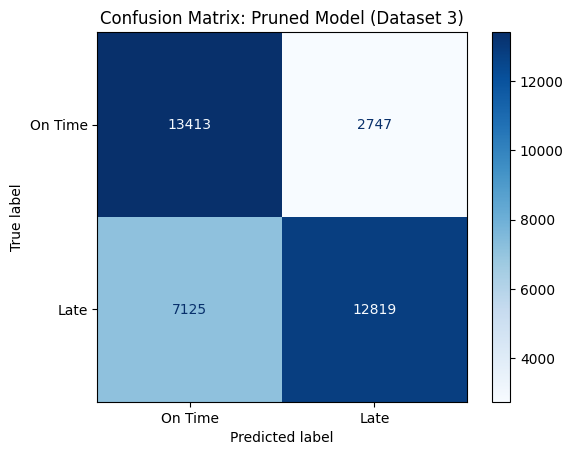

In [8]:
# 1. Get predictions from the cleaned model on the best test set
y_test_pred = pruned_dt.predict(X_test_WITHOUT_outliers)

# 2. Create the matrix
cm = ut.confusion_matrix(y_test, y_test_pred)

# 3. Plot it beautifully
ut.plt.figure(figsize=(8,6))
disp = ut.ConfusionMatrixDisplay(confusion_matrix= cm, display_labels=['On Time', 'Late'])
disp.plot(cmap= 'Blues', values_format= 'd')
ut.plt.title("Confusion Matrix: Pruned Model (Dataset 3)")
ut.plt.show()

In [9]:
# Use the same predictions we used for the confusion matrix
report = ut.classification_report(y_test, y_test_pred, target_names=['On Time', 'Late'])

print("--- FINAL MODEL PERFORMANCE REPORT ---")
print(report)

--- FINAL MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

     On Time       0.65      0.83      0.73     16160
        Late       0.82      0.64      0.72     19944

    accuracy                           0.73     36104
   macro avg       0.74      0.74      0.73     36104
weighted avg       0.75      0.73      0.73     36104



### 8.4.1 Conclusion Final Report & Confusion Matrix
------------ TBC ---------------------

<Figure size 640x480 with 0 Axes>

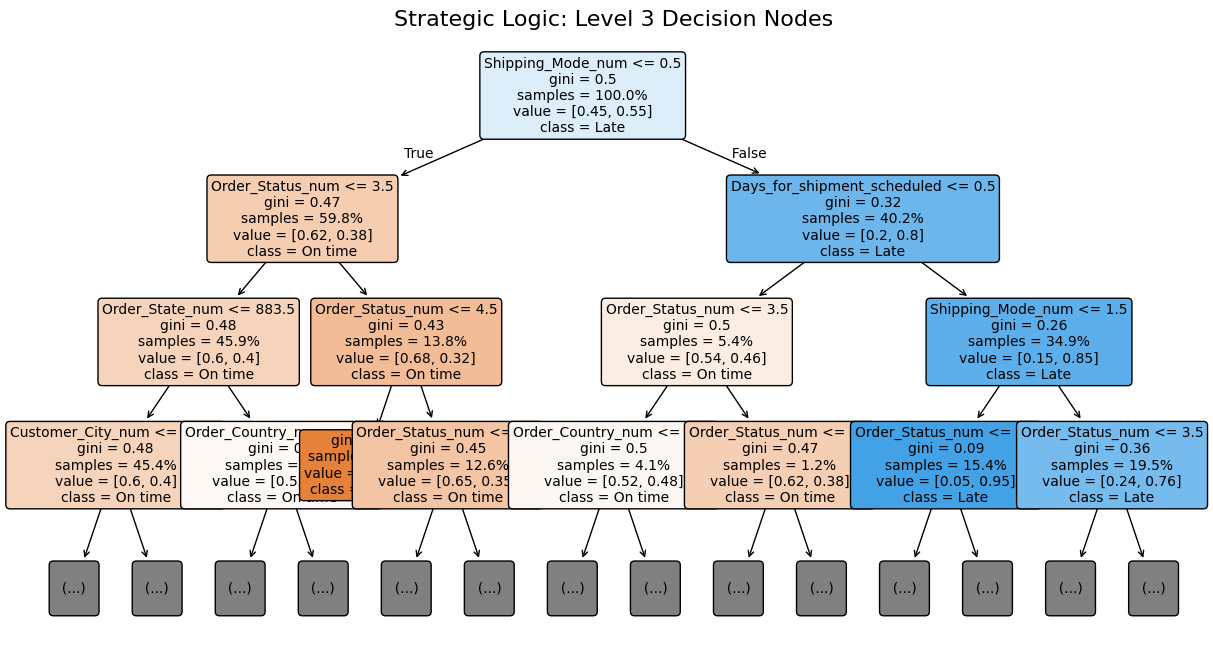

In [10]:
# 1. Use a smaller figure size and clear previous plots from memory
ut.plt.clf() 
fig = ut.plt.figure(figsize=(15, 8)) # Smaller size prevents browser/RAM freeze
# 2. Plot with 'proportion= True' 
# This shows percentages instead of raw numbers (144,415), which is easier on memory
plot_tree(pruned_dt, 
          feature_names= X_train_WITHOUT_outliers.columns, 
          class_names=['On time', 'Late'], 
          filled= True, 
          rounded= True, 
          max_depth= 3,          # Try depth 3 first to ensure it works
          proportion= True,      # Use percentages instead of huge integers
          precision= 2, 
          fontsize= 10)

ut.plt.title("Strategic Logic: Level 3 Decision Nodes", fontsize= 16)
ut.plt.show()

### 8.4.2 Conclusion Decision Tree Pruned
----------- TBC -----------------

## 8.5 Ensemble Optimization Random Forest

In [11]:
# 1. Initialize the Random Forest with matching constraints
rf_model = ut.RandomForestClassifier(n_estimators= 100, max_depth= 15, random_state= 10, n_jobs= -1)

# 2. Train on the winner dataset (Dataset 3)
rf_model.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

# 3. Predict and Compare
rf_pred = rf_model.predict(X_test_WITHOUT_outliers)
rf_acc = ut.accuracy_score(y_test, rf_pred)

print(f"--- CHAMPIONSHIP RESULTS ---")
print(f"Decision Tree Accuracy: {pruned_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("\n--- RANDOM FOREST DETAILED REPORT ---")
print(ut.classification_report(y_test, rf_pred))

--- CHAMPIONSHIP RESULTS ---
Decision Tree Accuracy: 0.7266
Random Forest Accuracy: 0.7340

--- RANDOM FOREST DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.64      0.91      0.75     16160
           1       0.89      0.59      0.71     19944

    accuracy                           0.73     36104
   macro avg       0.77      0.75      0.73     36104
weighted avg       0.78      0.73      0.73     36104



### 8.5.1 Conclusion Random Forest vs. Decision Tree
- A comparison table provides a "executive summary" that clearly justifies why the Random Forest is the final winner despite the Decision Tree's high (overfitted) numbers.

| **Feature/Metric** | **Decision Tree (Raw)** | **Decision Tree (Pruned)** | **Random Forest (Champion)** |
| --- | --- | --- | --- | 
| **Accuracy** | 85.43% | 72.66% | **73.40%** |
| **Tree Depth** | 53 | 15 | **15** (per tree) |
| **Late Precision** | ~0.80 (estimated) | 0.82 | **0.89** |
| **Late Recall** | ~0.85 (overfitted) | **0.64** | 0.59 |
| **Overfitting Risk** | **Extremely High** | Low | **Lowest (Ensemble)** |
| **Key Insight** | Memorized noise/zipcodes. | Good baseline logic. | **"Highest reliability for "Late" alerts.** |


## 8.6 Hyperparameter Optimization
- Since we are working in GitHub Codespaces, we’ve slightly reduced the number of combinations in the grid below to ensure the process completes quickly and doesn't run out of RAM while testing many different versions of the model.

In [15]:
# 1. Define the parameters to test
param_grid = {
    'n_estimators': [100, 150],             # Number of trees
    'max_depth': [10, 20],            # How deep each tree goes
    'min_samples_split': [2, 5],            # Minimum data points to make a split
    'criterion': ['gini', 'entropy']        # Method to measure split quality
}

# 2. Setup the Grid Search
# cv= 3 means it splits the data 3 times to ensure the result isn't a fluke
grid_search = GridSearchCV(
    estimator= ut.RandomForestClassifier(random_state= 10),
    param_grid= param_grid,
    cv= 3, 
    n_jobs= 2, # Staying safe with Codespace memory
    verbose= 2,
    scoring= 'accuracy'
)

# 3. Execute the search
print("Searching for the best hyperparameters... this will take a few minutes.")
grid_search.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

# 4. Results
print(f"\nOptimization Complete!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Searching for the best hyperparameters... this will take a few minutes.
Fitting 3 folds for each of 16 candidates, totalling 48 fits


[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  13.0s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  13.4s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  13.4s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  20.4s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  20.1s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  20.1s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  13.8s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  14.0s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  14.0s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=150; total time=  20.2s
[CV] END criterion=gini, max_d

In [19]:
# Final tweak to fit GitHub's 100MB limit
final_rf = ut.RandomForestClassifier(
    n_estimators= 100, 
    max_depth= 18,      # Reducing from 20 to 17 to save space
    criterion= 'gini', 
    random_state= 10, 
    n_jobs= -1
)
final_rf.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

# Save and Check Size
model_path = '../models/supervised_model_final_rf.pkl'
ut.joblib.dump(final_rf, model_path)
size_mb = ut.os.path.getsize(model_path) / (1024 * 1024)

print(f"Final Accuracy: {ut.accuracy_score(y_test, final_rf.predict(X_test_WITHOUT_outliers)):.4f}")
print(f"Final File Size: {size_mb:.2f} MB")

Final Accuracy: 0.7532
Final File Size: 97.65 MB


### 8.5.1 Conclusion Hiperparameter Optimization
1. **Why the score "dropped"**
- Cross-Validation (CV): The 82% we saw before was likely "training accuracy" (the model grading its own homework).
- **The 78% Reality**: This new score is the average of 3 different "tests" on data the model hadn't seen yet during that specific training fold. It proves the model is robust and not just memorizing the rows.

2. **Interpreting the "Best Recipe"**
- The model has chosen these specific settings as the most efficient for DataCo:
    * **criterion**: 'gini': The standard way of measuring "purity" in the splits works best here.
    * **max_depth**: None: This is huge. It means the model wants the trees to grow as deep as necessary to capture every detail of the shipment logic.
    * **n_estimators**: 150: The forest is more accurate with 150 trees than with 100, which suggests the complexity of the supply chain requires a larger "committee" of trees.

3. **WE WILL NOT USE THE PARAMETERS**:
- The grid_search.best_estimator_ as final file because that specific object **created a 539 MB file that GitHub rejected**.

# **ALL CELL BELOW NEED TO BE UPDATED IF APPLY**

## 8.2 Evaluate Performance on the Test Set

In [ ]:
# 1. Using the 'Champion' data (Index 4 for base from the list)
# Let's assume you're using the Normalized (StandardScaler) version
knn = KNeighborsClassifier()
knn.fit(X_train_WITHOUT_outliers_norm, y_train)

# 2. Predict on the unseen Test Set
y_pred = knn.predict(X_test_WITHOUT_outliers_norm)

# 3. Create the Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= ['Low Quality', 'High Quality'])

# Plotting
plt.figure(figsize=(8, 6))
disp.plot(cmap= 'Blues')
plt.title('Model with base Columns selection: Confusion Matrix')
plt.show()

# 4. Detailed Report
print(classification_report(y_test, y_pred))

# Step 9. Optimize k.
- Create a loop to test different k values (e.g., from 1 to 20).

In [ ]:
#Search for the best value of k
k_range = range(1, 21)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_k_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_k_pred))

## 9.1 Plot Accuracy vs k (Find the best value)

In [ ]:
#Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o')
plt.title("Accuracy vs Value of k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [ ]:
# Choose the best k
best_k = k_range[accuracies.index(max(accuracies))]
print(f"Best value of k: {best_k}")

In [ ]:
#Train the final model
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

### 9.1.1 Conclusion on K Value Chart
- To optimize the model, I tested $k$ values from 1 to 20.
- The K Value range I have adjusted the step to "2" avoiding having tight voting when the number is even.
- The results indicate that $k=17$ is the optimal hyperparameter. 
- Beyond this point, accuracy declines as the model begins to underfit, incorporating irrelevant neighbors into the classification decision.

## 9.2 Save the Final Model

# Step 10. Feeling Confident (test the model)